In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass, field
from typing import List, Tuple
from tqdm import tqdm
import os

os.makedirs('result', exist_ok=True)

In [11]:
@dataclass
class MonteCarloConfig:
    # 모드 설정: "paper" or "develop"
    mode: str = "develop"

    # 시뮬레이션 설정
    S0: float = 100.0
    T: float = 1.0
    sigma: float = 2.0
    drift: float = 0.0
    dt: float = 0.005
    n_steps: int = 200
    gamma: float = 0.1
    A: float = 140.0
    k: float = 1.5
    q0: int = 0

    # 방향성 체결 확률 버킷 (develop 모드 전용)
    buckets: List[Tuple[float, float]] = field(default_factory=lambda: [
        (0.02, 1.0),
        (0.05, 1.5),
        (0.10, 2.5),
        (float('inf'), 3.5)
    ])

    # 몬테카를로 설정
    n_simulations: int = 100000

# 모드 선택: "paper" 또는 "develop"
config = MonteCarloConfig(mode="paper")

In [12]:
# 핵심 함수들

def generate_mid_price_path(config: MonteCarloConfig) -> np.ndarray:
    Z = np.random.randn(config.n_steps)
    increments = config.drift * config.dt + config.sigma * np.sqrt(config.dt) * Z
    prices = np.zeros(config.n_steps + 1)
    prices[0] = config.S0
    prices[1:] = config.S0 + np.cumsum(increments)
    return prices

def compute_reservation_price(s: float, q: int, t: float, config: MonteCarloConfig) -> float:
    tau = config.T - t
    return s - q * config.gamma * (config.sigma ** 2) * tau

def compute_optimal_spread(t: float, config: MonteCarloConfig) -> float:
    tau = config.T - t
    return config.gamma * (config.sigma ** 2) * tau + (2 / config.gamma) * np.log(1 + config.gamma / config.k)

def compute_quotes(s: float, q: int, t: float, config: MonteCarloConfig) -> Tuple[float, float]:
    r = compute_reservation_price(s, q, t, config)
    spread = compute_optimal_spread(t, config)
    return r - spread / 2, r + spread / 2

def get_fill_multiplier(price_change_pct: float, config: MonteCarloConfig) -> float:
    """Develop 모드 전용: 방향성 체결 확률 승수"""
    abs_change = abs(price_change_pct)
    for threshold, multiplier in config.buckets:
        if abs_change < threshold:
            return multiplier
    return config.buckets[-1][1]

def compute_fill_probability_paper(delta: float, config: MonteCarloConfig) -> float:
    """Paper 모드: 기본 A-S 체결 확률"""
    if delta <= 0:
        return 0.0  # Paper 모드: delta <= 0 이면 체결 불가
    base_intensity = config.A * np.exp(-config.k * delta)
    return min(base_intensity * config.dt, 1.0)

def compute_fill_probability_develop(delta: float, s_current: float, s_next: float, 
                                      is_bid: bool, config: MonteCarloConfig, is_last_step: bool) -> float:
    """Develop 모드: 방향성 승수 + 즉시 체결"""
    if delta <= 0:
        return 1.0  # Develop 모드: delta <= 0 이면 즉시 체결
    
    base_intensity = config.A * np.exp(-config.k * delta)
    base_prob = min(base_intensity * config.dt, 1.0)
    
    if is_last_step:
        return base_prob
    
    price_change_pct = (s_next - s_current) / s_current * 100
    multiplier = get_fill_multiplier(price_change_pct, config)
    
    if price_change_pct > 0:
        if not is_bid:
            return min(base_prob * multiplier, 1.0)
        else:
            return max(base_prob / multiplier, 0.0)
    elif price_change_pct < 0:
        if is_bid:
            return min(base_prob * multiplier, 1.0)
        else:
            return max(base_prob / multiplier, 0.0)
    else:
        return base_prob

In [13]:
def run_single_simulation(config: MonteCarloConfig):
    """
    단일 시뮬레이션 실행 (paper/develop 모드 지원)
    Returns: (inventory_path, pnl_path, bid_fills, ask_fills)
    """
    mid_prices = generate_mid_price_path(config)
    
    inventory = config.q0
    cash = 0.0
    
    inventory_path = np.zeros(config.n_steps + 1)
    pnl_path = np.zeros(config.n_steps + 1)
    bid_fills = 0
    ask_fills = 0
    
    is_paper_mode = (config.mode == "paper")
    
    for step in range(config.n_steps):
        t = step * config.dt
        s = mid_prices[step]
        is_last_step = (step == config.n_steps - 1)
        s_next = mid_prices[step + 1] if not is_last_step else s
        
        bid, ask = compute_quotes(s, inventory, t, config)
        
        delta_bid = s - bid
        delta_ask = ask - s
        
        # 모드별 체결 확률 계산
        if is_paper_mode:
            prob_bid = compute_fill_probability_paper(delta_bid, config)
            prob_ask = compute_fill_probability_paper(delta_ask, config)
        else:
            prob_bid = compute_fill_probability_develop(delta_bid, s, s_next, True, config, is_last_step)
            prob_ask = compute_fill_probability_develop(delta_ask, s, s_next, False, config, is_last_step)
        
        bid_fill = np.random.random() < prob_bid
        ask_fill = np.random.random() < prob_ask
        
        # 모드별 체결 가격 결정
        if is_paper_mode:
            # Paper 모드: 항상 호가 가격에 체결
            bid_fill_price = bid
            ask_fill_price = ask
        else:
            # Develop 모드: delta <= 0 이면 mid price에 체결
            bid_fill_price = s if delta_bid <= 0 else bid
            ask_fill_price = s if delta_ask <= 0 else ask
        
        # 상태 기록
        inventory_path[step] = inventory
        pnl_path[step] = cash + inventory * s
        
        # 체결 처리
        if bid_fill:
            inventory += 1
            cash -= bid_fill_price
            bid_fills += 1
        if ask_fill:
            inventory -= 1
            cash += ask_fill_price
            ask_fills += 1
    
    # 최종 상태
    inventory_path[-1] = inventory
    pnl_path[-1] = cash + inventory * mid_prices[-1]
    
    return inventory_path, pnl_path, bid_fills, ask_fills

In [14]:
def run_monte_carlo(config: MonteCarloConfig):
    """
    몬테카를로 시뮬레이션 실행 (메모리 효율적 집계)
    """
    n_sims = config.n_simulations
    n_steps = config.n_steps + 1
    
    # 실시간 집계용 배열
    inv_sum = np.zeros(n_steps)
    inv_sq_sum = np.zeros(n_steps)
    pnl_sum = np.zeros(n_steps)
    pnl_sq_sum = np.zeros(n_steps)
    
    # 최종 값 저장
    final_inventory = np.zeros(n_sims)
    final_pnl = np.zeros(n_sims)
    total_bid_fills = 0
    total_ask_fills = 0
    
    print(f"Running {n_sims:,} simulations... (Mode: {config.mode})")
    
    for i in tqdm(range(n_sims)):
        np.random.seed(i)  # 재현성
        inv_path, pnl_path, bid_fills, ask_fills = run_single_simulation(config)
        
        # 실시간 집계
        inv_sum += inv_path
        inv_sq_sum += inv_path ** 2
        pnl_sum += pnl_path
        pnl_sq_sum += pnl_path ** 2
        
        # 최종 값
        final_inventory[i] = inv_path[-1]
        final_pnl[i] = pnl_path[-1]
        total_bid_fills += bid_fills
        total_ask_fills += ask_fills
    
    # 통계 계산
    inv_mean = inv_sum / n_sims
    inv_std = np.sqrt(np.maximum(inv_sq_sum / n_sims - inv_mean ** 2, 0))
    pnl_mean = pnl_sum / n_sims
    pnl_std = np.sqrt(np.maximum(pnl_sq_sum / n_sims - pnl_mean ** 2, 0))
    
    results = {
        'inv_mean': inv_mean,
        'inv_std': inv_std,
        'pnl_mean': pnl_mean,
        'pnl_std': pnl_std,
        'final_inventory': final_inventory,
        'final_pnl': final_pnl,
        'avg_bid_fills': total_bid_fills / n_sims,
        'avg_ask_fills': total_ask_fills / n_sims,
    }
    
    print(f"\nCompleted! Avg fills per sim: bid={results['avg_bid_fills']:.1f}, ask={results['avg_ask_fills']:.1f}")
    
    return results

In [15]:
# 몬테카를로 시뮬레이션 실행
results = run_monte_carlo(config)

Running 100,000 simulations... (Mode: paper)


100%|██████████| 100000/100000 [03:01<00:00, 550.47it/s]


Completed! Avg fills per sim: bid=45.2, ask=45.1


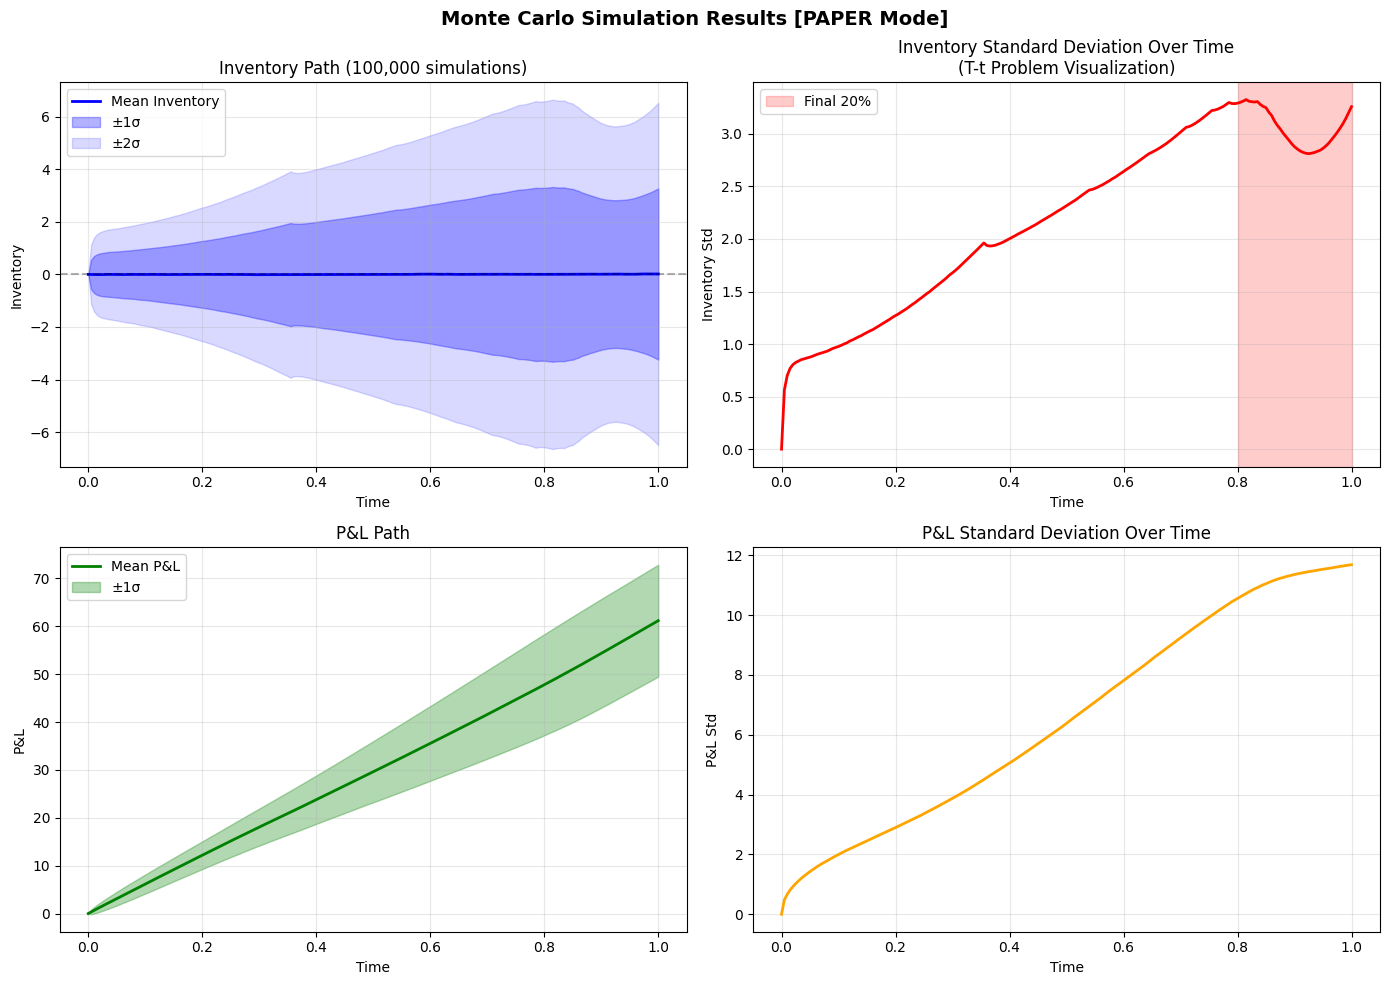

In [16]:
# 시간 배열
times = np.linspace(0, config.T, config.n_steps + 1)
mode_label = config.mode.upper()

# 1. 시간에 따른 재고 경로 (평균 + 신뢰구간)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Monte Carlo Simulation Results [{mode_label} Mode]', fontsize=14, fontweight='bold')

# 재고 경로
ax = axes[0, 0]
ax.plot(times, results['inv_mean'], 'b-', linewidth=2, label='Mean Inventory')
ax.fill_between(times, 
                results['inv_mean'] - results['inv_std'], 
                results['inv_mean'] + results['inv_std'], 
                alpha=0.3, color='blue', label='±1σ')
ax.fill_between(times, 
                results['inv_mean'] - 2*results['inv_std'], 
                results['inv_mean'] + 2*results['inv_std'], 
                alpha=0.15, color='blue', label='±2σ')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.set_xlabel('Time')
ax.set_ylabel('Inventory')
ax.set_title(f'Inventory Path ({config.n_simulations:,} simulations)')
ax.legend()
ax.grid(True, alpha=0.3)

# 재고 표준편차 (T-t 문제 시각화)
ax = axes[0, 1]
ax.plot(times, results['inv_std'], 'r-', linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel('Inventory Std')
ax.set_title('Inventory Standard Deviation Over Time\n(T-t Problem Visualization)')
ax.grid(True, alpha=0.3)
# 막판 구간 강조
ax.axvspan(0.8, 1.0, alpha=0.2, color='red', label='Final 20%')
ax.legend()

# P&L 경로
ax = axes[1, 0]
ax.plot(times, results['pnl_mean'], 'g-', linewidth=2, label='Mean P&L')
ax.fill_between(times, 
                results['pnl_mean'] - results['pnl_std'], 
                results['pnl_mean'] + results['pnl_std'], 
                alpha=0.3, color='green', label='±1σ')
ax.set_xlabel('Time')
ax.set_ylabel('P&L')
ax.set_title('P&L Path')
ax.legend()
ax.grid(True, alpha=0.3)

# P&L 표준편차
ax = axes[1, 1]
ax.plot(times, results['pnl_std'], 'orange', linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel('P&L Std')
ax.set_title('P&L Standard Deviation Over Time')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'result/monte_carlo_paths_{config.mode}.png', dpi=150)
plt.show()

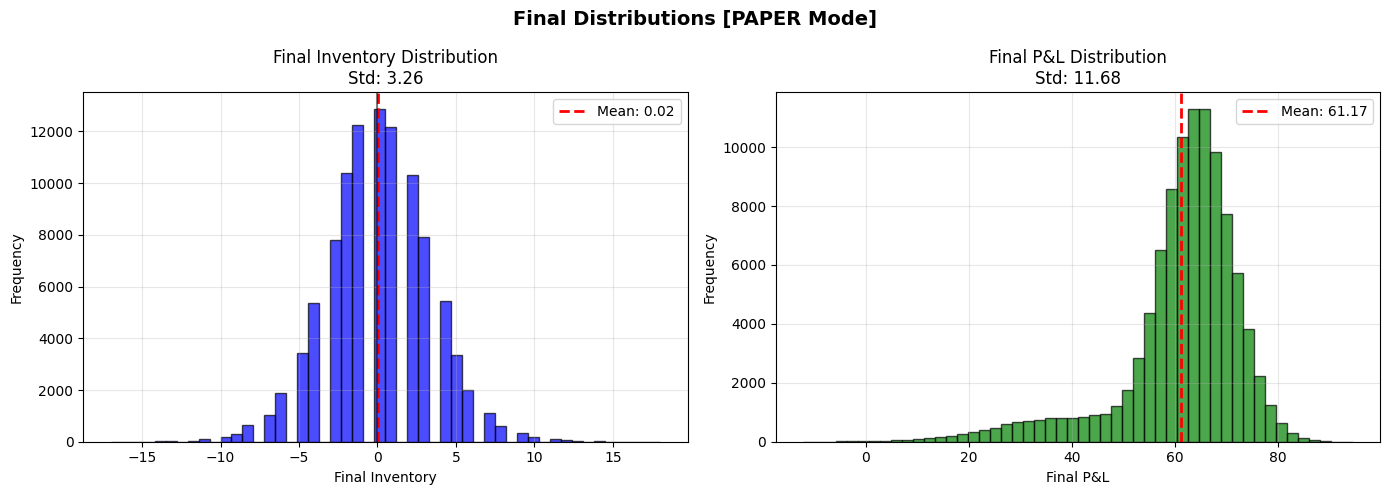

In [17]:
# 2. 최종 분포 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Final Distributions [{mode_label} Mode]', fontsize=14, fontweight='bold')

# Final Inventory 분포
ax = axes[0]
ax.hist(results['final_inventory'], bins=50, alpha=0.7, color='blue', edgecolor='black')
ax.axvline(x=np.mean(results['final_inventory']), color='red', linestyle='--', linewidth=2,
           label=f"Mean: {np.mean(results['final_inventory']):.2f}")
ax.axvline(x=0, color='black', linestyle='-', alpha=0.5)
ax.set_xlabel('Final Inventory')
ax.set_ylabel('Frequency')
ax.set_title(f'Final Inventory Distribution\nStd: {np.std(results["final_inventory"]):.2f}')
ax.legend()
ax.grid(True, alpha=0.3)

# Final P&L 분포
ax = axes[1]
ax.hist(results['final_pnl'], bins=50, alpha=0.7, color='green', edgecolor='black')
ax.axvline(x=np.mean(results['final_pnl']), color='red', linestyle='--', linewidth=2,
           label=f"Mean: {np.mean(results['final_pnl']):.2f}")
ax.set_xlabel('Final P&L')
ax.set_ylabel('Frequency')
ax.set_title(f'Final P&L Distribution\nStd: {np.std(results["final_pnl"]):.2f}')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'result/monte_carlo_distributions_{config.mode}.png', dpi=150)
plt.show()

In [18]:
# 3. 통계 요약
print("=" * 60)
print(f"Monte Carlo Simulation Results [{config.mode.upper()} Mode]")
print(f"({config.n_simulations:,} runs)")
print("=" * 60)
print(f"\nMode: {config.mode}")
if config.mode == "paper":
    print("  - 기본 A-S 체결 확률")
    print("  - delta <= 0: 체결 불가")
    print("  - 체결 가격: 호가 가격")
else:
    print("  - 방향성 체결 확률 승수 적용")
    print("  - delta <= 0: 즉시 체결")
    print("  - 체결 가격: delta <= 0이면 mid price")
print(f"\nParameters:")
print(f"  n_steps: {config.n_steps}, dt: {config.dt}")
print(f"  sigma: {config.sigma}, gamma: {config.gamma}")
print(f"  A: {config.A}, k: {config.k}")
print(f"  drift: {config.drift}")
print(f"\nFill Statistics:")
print(f"  Avg Bid Fills: {results['avg_bid_fills']:.2f}")
print(f"  Avg Ask Fills: {results['avg_ask_fills']:.2f}")
print(f"\nFinal Inventory:")
print(f"  Mean: {np.mean(results['final_inventory']):.4f}")
print(f"  Std:  {np.std(results['final_inventory']):.4f}")
print(f"  Min:  {np.min(results['final_inventory']):.0f}")
print(f"  Max:  {np.max(results['final_inventory']):.0f}")
print(f"\nFinal P&L:")
print(f"  Mean: {np.mean(results['final_pnl']):.2f}")
print(f"  Std:  {np.std(results['final_pnl']):.2f}")
print(f"  5th percentile:  {np.percentile(results['final_pnl'], 5):.2f}")
print(f"  95th percentile: {np.percentile(results['final_pnl'], 95):.2f}")
print(f"\n(T-t) Problem Indicator:")
print(f"  Inventory Std at t=0.5: {results['inv_std'][config.n_steps//2]:.4f}")
print(f"  Inventory Std at t=0.9: {results['inv_std'][int(config.n_steps*0.9)]:.4f}")
print(f"  Inventory Std at t=1.0: {results['inv_std'][-1]:.4f}")
print(f"  Ratio (t=1.0 / t=0.5): {results['inv_std'][-1] / max(results['inv_std'][config.n_steps//2], 0.0001):.2f}x")

Monte Carlo Simulation Results [PAPER Mode]
(100,000 runs)

Mode: paper
  - 기본 A-S 체결 확률
  - delta <= 0: 체결 불가
  - 체결 가격: 호가 가격

Parameters:
  n_steps: 200, dt: 0.005
  sigma: 2.0, gamma: 0.1
  A: 140.0, k: 1.5
  drift: 0.0

Fill Statistics:
  Avg Bid Fills: 45.16
  Avg Ask Fills: 45.15

Final Inventory:
  Mean: 0.0161
  Std:  3.2586
  Min:  -17
  Max:  18

Final P&L:
  Mean: 61.17
  Std:  11.68
  5th percentile:  34.91
  95th percentile: 75.01

(T-t) Problem Indicator:
  Inventory Std at t=0.5: 2.3169
  Inventory Std at t=0.9: 2.8776
  Inventory Std at t=1.0: 3.2586
  Ratio (t=1.0 / t=0.5): 1.41x
